In [1]:
%pylab inline
import pandas as pd
import numpy as np
from matplotlib import style
import matplotlib.pyplot as plt
import os

import scipy.fftpack
import scipy.signal
import scipy.io.wavfile
from scipy import stats
from scipy import signal

from open_ephys.analysis import Session

plt.rcParams['font.size'] = 20

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


c:\Users\cestarellas\anaconda3\envs\PLAna\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Digital data
#Load file
# Open the file in read mode
file_name = 'D:\\_work_cestarellas\\Analysis\\OFC_vs_PrL_project\\OFC\\JG15_190724_clustered\\digitalin.dat'


In [9]:
import struct
file_size = os.path.getsize(file_name)

# Calculate the number of samples (uint16 = 2 bytes)
num_samples = file_size // 2

# Read the binary file
with open(file_name, 'rb') as fid:
    # Read the data as uint16
    digital_word = np.fromfile(fid, dtype=np.uint16, count=num_samples)

# Print the digital word (optional)
print(digital_word)

# Calculate digital inputs
digital_input_0 = (digital_word & (1 << 0)) > 0
digital_input_1 = (digital_word & (1 << 1)) > 0
digital_input_2 = (digital_word & (1 << 2)) > 0
digital_input_3 = (digital_word & (1 << 3)) > 0
digital_input_4 = (digital_word & (1 << 4)) > 0
digital_input_5 = (digital_word & (1 << 5)) > 0

[16  0  0 ...  0  0  0]


In [11]:
digital_in_channels=1   # the max index of active digital channel starting with 0 if only one channel is active, 1 for the first two and so on
digital_inputs=np.fromfile(file_name, dtype='>i2')
digital_inputs = (digital_inputs/256).astype('int')
#digital_inputs=pd.DataFrame(digital_inputs/256).astype(int)


TTL1=np.bitwise_and(digital_inputs,(2**0))>0 # what the fuck does ttl1 represent
#TTL1=pd.DataFrame(TTL1).astype(int)

TTL2=np.bitwise_and(digital_inputs,(2**1))>0
#TTL2=pd.DataFrame(TTL2).astype(int)

TTL3=(np.bitwise_and(digital_inputs,(2**3))>0)  # information from digital input channel 4 coding for the other pin of the rotary encoder
#TTL3=pd.DataFrame(TTL3).astype(int) # information from digital input channel 4

TTL5=(np.bitwise_and(digital_inputs,(2**5))>0) # information from digital input channel 5 coding for one pin of the rotary encoder
#TTL5=pd.DataFrame(TTL5).astype(int) #information from digital input channel 5

TTL4=(np.bitwise_and(digital_inputs,(2**4))>0)  # information from digital input channel 4 coding for the other pin of the rotary encoder
#TTL4=pd.DataFrame(TTL4).astype(int) # information from digital input channel 4


In [12]:
TTL3

array([ True,  True,  True, ..., False, False, False])

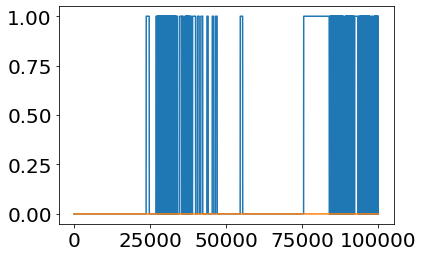

In [74]:
plt.figure()
plt.plot(TTL3[0:100000])
plt.plot(TTL1[0:100000])


Text(0, 0.5, "Animal's choice")

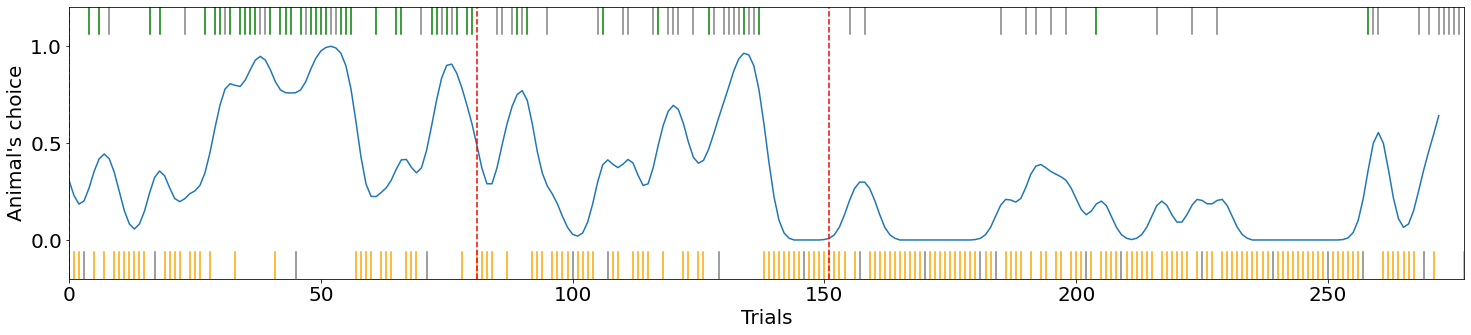

In [15]:
'''
Panels of Figure 1: Behaviour of mice in Gambling task
The behaviour is based on the next table:
# Info Columns BehData:
# 0- Trial Start
# 1- Trial End
# 2- Duration (Seconds)
# 3- Block
# 4- Gamble Arm (Right = 1, Left = 0)
# 5- Probability big Reward
# 6- Probability Small Reward
# 7- Ammount Big Reward
# 8- Ammount Small Reward
# 9- Number of previously wheel not stopping
# 10- Not responding Trial
# 11- Chosen Side (Right = 1, Left = 0)
# 12- Chosen Arm (Gamble = 1, Safe = 0)
# 13- Reward Given
# 14- Start of the trial (Sampling points)
# 15- Cue Presentation (Sampling Points)
# 16- Start of the response window (Sampling Points)
# 17- Reward Period (Sampling Points)
# 18- End of the trial

In this code there are the next plots:
1) Example of the behaviour for a specific session
2) Boxplot of the choice gamble side in each probability block
'''


#%% Libraries
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
plt.rcParams['font.size'] = 20

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% Plot Behaviour %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

path='D:/_work_cestarellas/Analysis/PLRNN/Session_Selected/OFC/JG15_190724_clustered'   # Pathway of the data (behaviour & Spike activity)

# Selection of the file
os.chdir(path)
list_files = os.listdir(path)
for i in list_files:
    if i.find('Behaviour')>0:
        Behaviour_name = i

# Load data
# Open the Behaviour file
Bdata = scipy.io.loadmat(Behaviour_name)
BehData = Bdata[list(Bdata.keys())[-1]]

# Classification of trials following the behabiour
GambleRewardTrials = np.where((BehData[:,12]==1) & (BehData[:,13]==1))[0]
GambleNoRewardTrials =  np.where((BehData[:,12]==1) & (BehData[:,13]==0))[0]
SafeRewardTrials = np.where((BehData[:,12]==0) & (BehData[:,13]==1))[0]
SafeNoRewardTrials = np.where((BehData[:,12]==0) & (BehData[:,13]==0))[0]
NoRespondingTrials = np.where(BehData[:,10]==1)[0]

# Blocks
Block_Prob = np.unique(BehData[:,5])
BlockTrials = [np.where(Block_Prob[i]==BehData[:,5])[0][0] for i in range(len(Block_Prob))]
# Smoothing the data for plotting
ScaleDecision=BehData[:,12]+(BehData[:,12]-1)
SigmaDecision=1
Binx =0.5
KernelWindow = np.arange(-3*SigmaDecision, 3*SigmaDecision, Binx)
KernelDecision = np.exp(-(KernelWindow/SigmaDecision)**2/2)
DecisionConvolution=np.convolve(ScaleDecision,KernelDecision,mode='same')
DecisionNormalized=(DecisionConvolution/np.nanmax(np.abs(DecisionConvolution))+1)/2
if NoRespondingTrials[0]<20:
    first_trial = NoRespondingTrials[0]+1
    last_trial = NoRespondingTrials[1]-1
else:
    first_trial = 0
    last_trial = NoRespondingTrials[0]-1
    
first_trial = 0
last_trial = NoRespondingTrials[0]-1

# FIGURE: Plot behaviour performance
plt.figure(figsize=(25,5))
plt.plot(DecisionNormalized)
for i in GambleRewardTrials:
    plt.axvline(i,ymin=0.9,ymax=1.0,color='g') 
for i in GambleNoRewardTrials:
    plt.axvline(i,ymin=0.9,ymax=1.0,color='gray')
for i in SafeRewardTrials:
    plt.axvline(i,ymin=0.0,ymax=0.1,color='orange')
for i in SafeNoRewardTrials:
    plt.axvline(i,ymin=0.0,ymax=0.1,color='gray')
for i in NoRespondingTrials:
    plt.axvline(i,ymin=0.45,ymax=0.55,color='blue')
for i in BlockTrials:
    plt.axvline(i,linestyle='dashed',color='r',)     
plt.ylim([-0.2,1.2])
plt.yticks(ticks=[1.0,0.5,0.0])
plt.xlim([first_trial,last_trial])
plt.xlabel('Trials')
plt.ylabel("Animal's choice")




In [20]:
BehData[0,14]

274578.0

In [13]:
TTL3.shape

(45701760,)

In [16]:

# Assign TTL signals
TTL1 = digital_input_3
TTL2 = digital_input_4

# Variable initialization
encoderCPR = 1024  # Encoder resolution
Position = 0  # Relative start position

# Position decoding
A = np.diff(TTL1.astype(int))
IndexA = np.where(A == 1)[0] + 1
Overall_Movement = np.zeros(len(TTL1))

count = 1
count_trial = 1

# Assuming Trials_Sync is defined somewhere
# For demonstration, I'm initializing a dummy Trials_Sync array
# Replace this with the actual Trials_Sync array
Trials_Sync = np.array([[0]*16]*10)  # Example placeholder

for i in range(len(TTL1)):
    # Reset Position in each new trial
    if count_trial <= len(Trials_Sync[:, 0]):
        if i == Trials_Sync[count_trial-1, 14]:  # Adjust for zero-based index
            Position = 0
            count_trial += 1

    if count <= len(IndexA):
        if i == IndexA[count-1]:  # Adjust for zero-based index
            # Checking the value of the pin B when there is movement in A
            if TTL2[i] == 0:
                Position += 360 / encoderCPR
            else:
                Position -= 360 / encoderCPR
            count += 1

    Overall_Movement[i] = Position

# Print the overall movement (optional)
print(Overall_Movement)

[     0.             0.             0.        ... -17123.5546875
 -17123.5546875 -17123.5546875]
